In [1]:
# Parameters
megadescriptor_version = 'L-384'  # 'S-224', 'B-224', 'L-384'
detection = '_seg' # '', _detected', '_detected_manual', '_seg'
mode = 'wb_' # '', 'wb_' Grayscale or not
seed = 42
query_ratio = 0.2

In [2]:
# Parameters
megadescriptor_version = "B-224"
detection = "_seg"
mode = ""
seed = 0
query_ratio = 0.2


In [3]:
import torch
import numpy as np
import joblib
import torch.nn as nn
import torch.optim as optim
import random
from collections import defaultdict

In [4]:
np.random.seed(seed)

# Path to new file (mode + model version)
base_path = "saved_models_wb_seg"

data_path = f"{base_path}/{str(mode)}segmentation/{megadescriptor_version}/data.npz"
encoder_path = f"{base_path}/{str(mode)}segmentation/{megadescriptor_version}/label_encoder.pkl"

# Load everything at once
data = np.load(data_path)

embeddings = data["embeddings"]      # shape (N, D)
labels = data["label_ids"]           # integer labels

print("Embeddings shape:", embeddings.shape)

# Load encoder
encoder = joblib.load(encoder_path)

# Optional name mappings
names = encoder.inverse_transform(labels)

id_to_name = dict(enumerate(encoder.classes_))
name_to_id = {v: k for k, v in id_to_name.items()}

Embeddings shape: (272, 1024)


In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedShuffleSplit

def evaluate_accuracy_np(embeddings, labels, query_ratio=0.2, seed=0):

    idx = np.arange(len(labels))
    embeddings = embeddings[idx]
    labels = labels[idx]

    # deterministic stratified split
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=query_ratio,
        random_state=seed
    )

    db_idx, q_idx = next(sss.split(embeddings, labels))

    db_emb = embeddings[db_idx]
    db_labels = labels[db_idx]

    q_emb = embeddings[q_idx]
    q_labels = labels[q_idx]

    # L2 normalization (safe guard against zero vectors)
    db_norm = np.linalg.norm(db_emb, axis=1, keepdims=True)
    q_norm = np.linalg.norm(q_emb, axis=1, keepdims=True)

    db_emb = db_emb / np.clip(db_norm, 1e-12, None)
    q_emb = q_emb / np.clip(q_norm, 1e-12, None)

    # cosine similarity
    sim = cosine_similarity(q_emb, db_emb)

    nearest = np.argmax(sim, axis=1)
    predictions = db_labels[nearest]

    accuracy = np.mean(predictions == q_labels)

    print(f"[seed={seed}] Query ratio: {query_ratio} | Accuracy: {accuracy:.4f}")

    return accuracy

In [6]:
accuracy = evaluate_accuracy_np(embeddings, labels, query_ratio=query_ratio, seed=seed)

[seed=0] Query ratio: 0.2 | Accuracy: 0.4545


C:\Users\user\AppData\Local\Temp\ipykernel_7532\1123045260.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_classes)


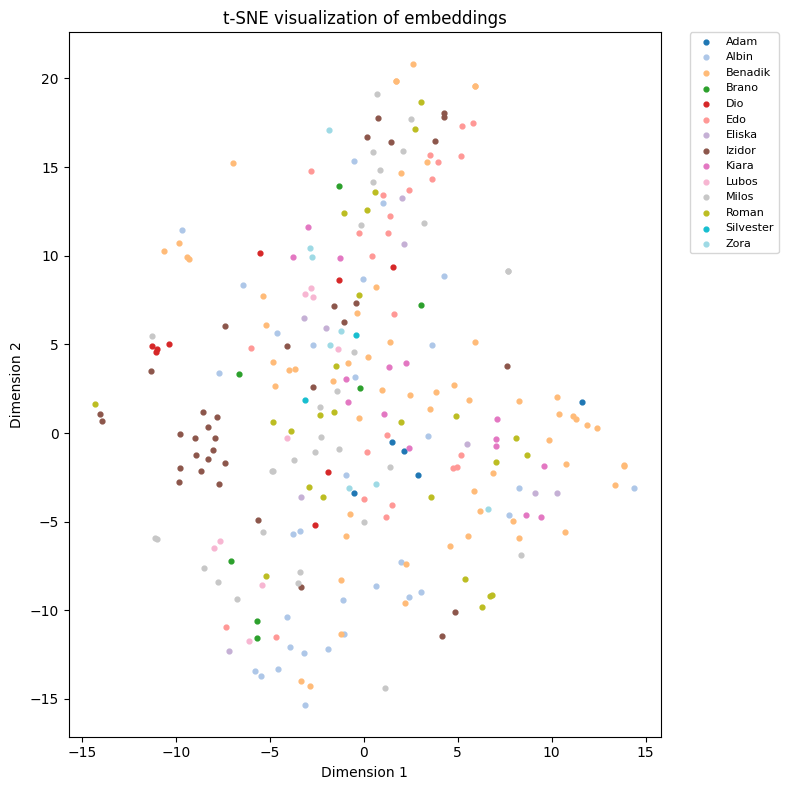

In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

unique_labels = np.unique(labels)
num_classes = len(unique_labels)

# Use high-contrast categorical colormap
cmap = cm.get_cmap('tab20', num_classes)

plt.figure(figsize=(8, 8))

for label in unique_labels:
    mask = labels == label
    
    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=12,
        color=cmap(label),              # use label as color index
        label=id_to_name[label]         # use class name in legend
    )

plt.title("t-SNE visualization of embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [8]:
result = {
    "megadescriptor_version": megadescriptor_version,
    "dataset_version": detection,
    "seed": seed,
    "query_ratio": query_ratio,
    "accuracy": accuracy,
    "mode": mode == 'wb_'
}

result

{'megadescriptor_version': 'B-224',
 'dataset_version': '_seg',
 'seed': 0,
 'query_ratio': 0.2,
 'accuracy': 0.45454545454545453,
 'mode': False}